Name: Sonal Shinde  
Division: C  
Roll no. 38

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Dataset
from tensorflow.keras.datasets import imdb

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

## 1. Load Dataset

In [2]:
# Load dataset (Top 10,000 words)
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


## 2. Data Preprocessing

In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

## 3. Data Visualization

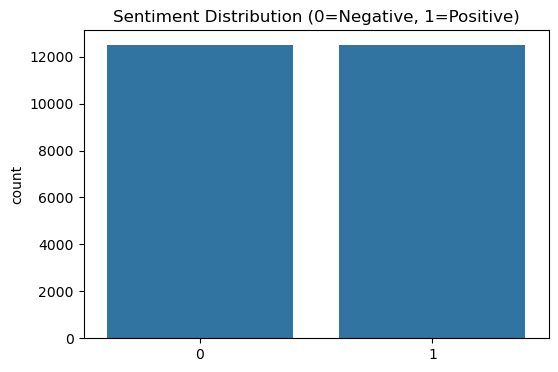

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Sentiment Distribution (0=Negative, 1=Positive)")
plt.show()

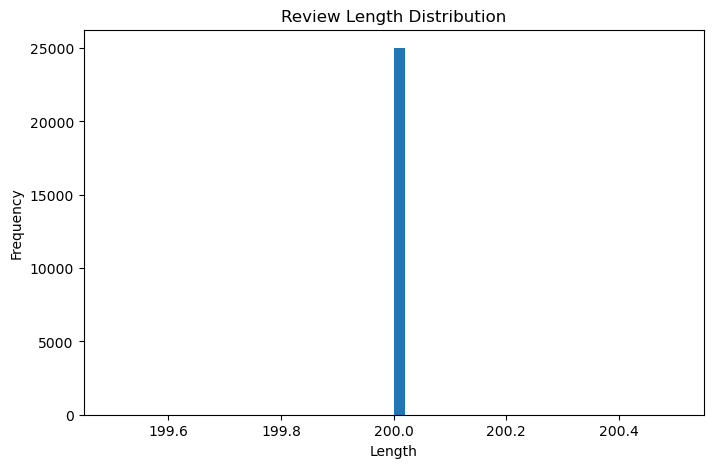

In [5]:
review_lengths = [len(x) for x in X_train]

plt.figure(figsize=(8,5))
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 4. Build LSTM Model

In [6]:
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

# LSTM layer
model.add(LSTM(128, return_sequences=False))

# Dropout
model.add(Dropout(0.5))

# Output layer (Binary classification)
model.add(Dense(1, activation='sigmoid'))

C:\Users\sonal\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 5. Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 6. Train Model

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 342s 856ms/step - accuracy: 0.7059 - loss: 0.5378 - val_accuracy: 0.8448 - val_loss: 0.3570
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.9013 - loss: 0.2600 - val_accuracy: 0.8633 - val_loss: 0.3193
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 289s 733ms/step - accuracy: 0.9347 - loss: 0.1800 - val_accuracy: 0.8553 - val_loss: 0.3694
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 403ms/step - accuracy: 0.9465 - loss: 0.1455 - val_accuracy: 0.8626 - val_loss: 0.4064
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 178s 456ms/step - accuracy: 0.9640 - loss: 0.1033 - val_accuracy: 0.8501 - val_loss: 0.5164


## 7. Evaluate Model

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8481 - loss: 0.5332
Test Accuracy: 0.8501200079917908


## 8. Predictions

In [11]:
y_pred = model.predict(X_test)

# Convert probabilities to binary
y_pred_classes = (y_pred > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step


## 9. Confusion Matrix

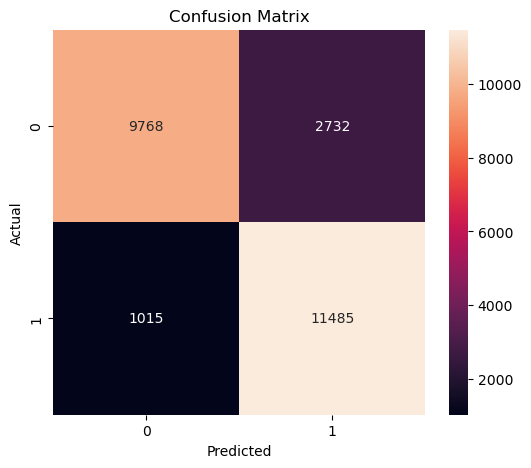

In [12]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10. Classification Report

In [13]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84     12500
           1       0.81      0.92      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



## 11. Accuracy Graph

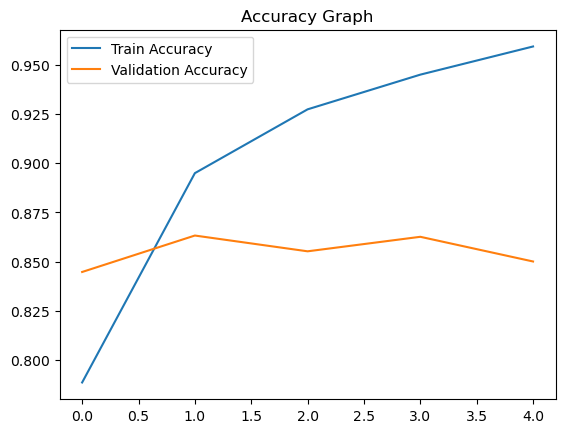

In [14]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.legend()
plt.show()

## 12. Loss Graph

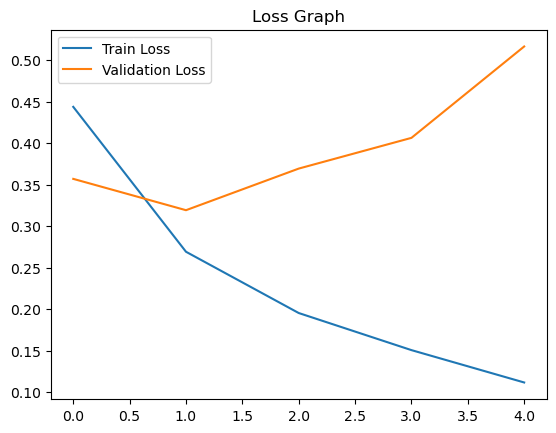

In [15]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Graph")
plt.legend()
plt.show()

## 13. Sample Predictions

In [16]:
for i in range(5):
    print("Prediction:", "Positive" if y_pred[i] > 0.5 else "Negative",
          "| Actual:", "Positive" if y_test[i]==1 else "Negative")

Prediction: Positive | Actual: Negative
Prediction: Positive | Actual: Positive
Prediction: Positive | Actual: Positive
Prediction: Negative | Actual: Negative
Prediction: Positive | Actual: Positive
